In [1]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [2]:
orders.head()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [3]:
customers.head()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [4]:
items.head()
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [5]:
products.head()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [6]:
payments.head()
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [7]:
# Convert date
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [8]:
# Merge orders + customers
df = orders.merge(customers, on='customer_id', how='left')

# Merge with order items
df = df.merge(items, on='order_id', how='left')

# Merge with products
df = df.merge(products, on='product_id', how='left')

# Merge with payments
df = df.merge(payments, on='order_id', how='left')

In [9]:
df['revenue'] = df['price'] + df['freight_value']

In [10]:
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

In [11]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118434 non-null  object        
 1   customer_id                    118434 non-null  object        
 2   order_status                   118434 non-null  object        
 3   order_purchase_timestamp       118434 non-null  datetime64[ns]
 4   order_approved_at              118258 non-null  object        
 5   order_delivered_carrier_date   116360 non-null  object        
 6   order_delivered_customer_date  115037 non-null  object        
 7   order_estimated_delivery_date  118434 non-null  object        
 8   customer_unique_id             118434 non-null  object        
 9   customer_zip_code_prefix       118434 non-null  int64         
 10  customer_city                  118434 non-null  object        
 11  

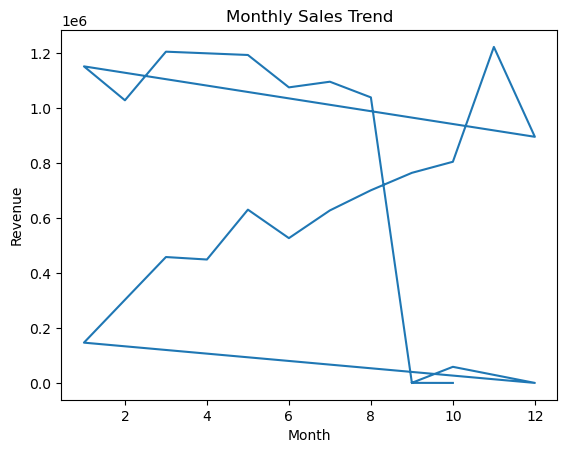

In [12]:
#1. Monthly Sales Trend

monthly_sales = df.groupby(['year','month'])['revenue'].sum().reset_index()

import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_sales['month'], monthly_sales['revenue'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

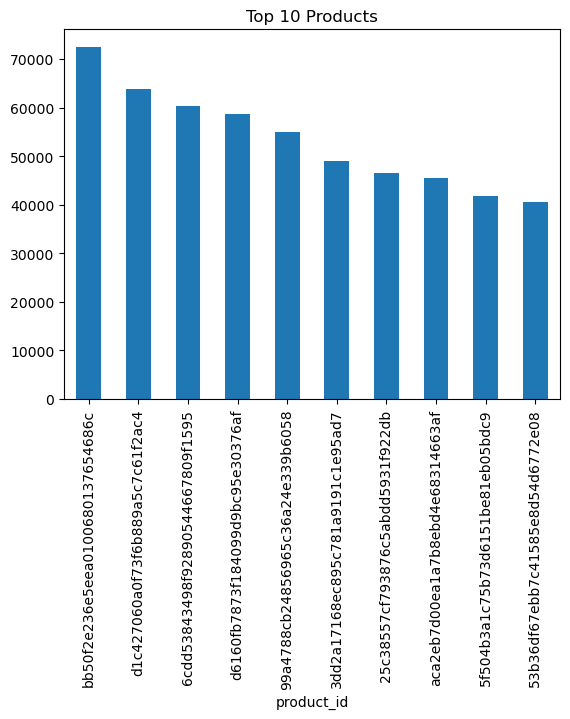

In [13]:
#2. Top 10 products

top_products = df.groupby('product_id')['revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.show()

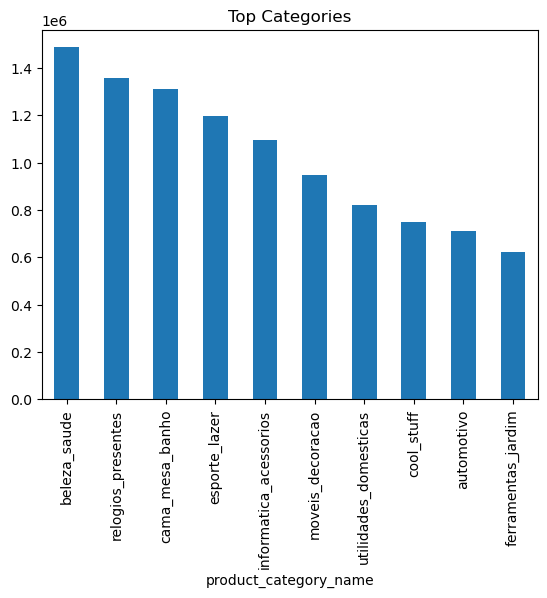

In [14]:
#3. Top Categories

top_categories = df.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar')
plt.title("Top Categories")
plt.show()

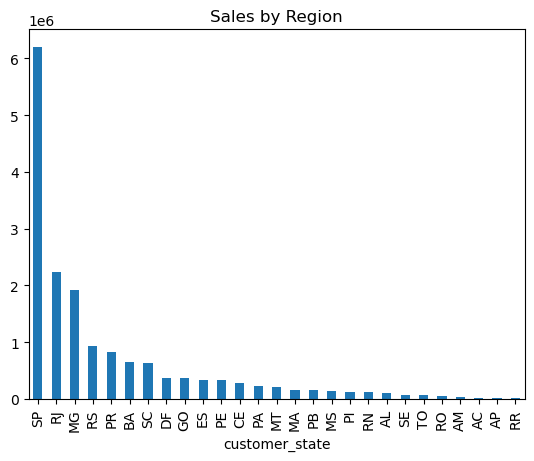

In [15]:
#4. Region-wise Sales

region_sales = df.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

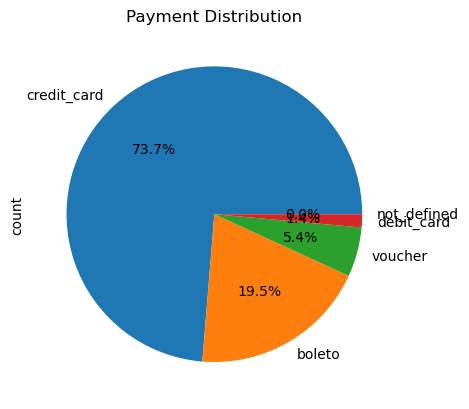

In [16]:
#5. Payment Type Distribution

payment = df['payment_type'].value_counts()

payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Distribution")
plt.show()

In [17]:
import sqlite3
conn = sqlite3.connect("Ecommerce")

In [18]:
orders.to_sql("orders", conn, index=False, if_exists='replace')
customers.to_sql("customers", conn, index=False, if_exists='replace')
items.to_sql("order_items", conn, index=False, if_exists='replace')
products.to_sql("products", conn, index=False, if_exists='replace')
payments.to_sql("payments", conn, index=False, if_exists='replace')

103886

In [19]:
import pandas as pd

pd.read_sql("SELECT * FROM orders LIMIT 5;", conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [20]:
#Monthly Sales

query = """
SELECT 
    strftime('%Y', order_purchase_timestamp) AS year,
    strftime('%m', order_purchase_timestamp) AS month,
    SUM(price + freight_value) AS revenue
FROM orders o
JOIN order_items i ON o.order_id = i.order_id
GROUP BY year, month
ORDER BY year, month;
"""

pd.read_sql(query, conn)

,year,month,revenue
0,2016,09,354.75
1,2016,10,56808.84
2,2016,12,19.62
3,2017,01,137188.49
4,2017,02,286280.62
5,2017,03,432048.59
6,2017,04,412422.24
7,2017,05,586190.95
8,2017,06,502963.04
9,2017,07,584971.62


In [21]:
#Top Products

query = """
SELECT product_id, SUM(price + freight_value) AS revenue
FROM order_items
GROUP BY product_id
ORDER BY revenue DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,product_id,revenue
0,bb50f2e236e5eea0100680137654686c,67606.10
1,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03
2,6cdd53843498f92890544667809f1595,59093.99
3,99a4788cb24856965c36a24e339b6058,51071.60
4,d6160fb7873f184099d9bc95e30376af,50326.18
5,3dd2a17168ec895c781a9191c1e95ad7,48212.22
6,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76
7,5f504b3a1c75b73d6151be81eb05bdc9,41725.81
8,25c38557cf793876c5abdd5931f922db,40311.95
9,53b36df67ebb7c41585e8d54d6772e08,39957.93


In [22]:
#Region-wise Sales

query = """
SELECT customer_state, SUM(price + freight_value) AS revenue
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
JOIN order_items i ON o.order_id = i.order_id
GROUP BY customer_state
ORDER BY revenue DESC;
"""

pd.read_sql(query, conn)

,customer_state,revenue
0,SP,5921678.12
1,RJ,2129681.98
2,MG,1856161.49
3,RS,885826.76
4,PR,800935.44
5,BA,611506.67
6,SC,610213.60
7,DF,353229.44
8,GO,347706.93
9,ES,324801.91


In [23]:
monthly = df.groupby(['year','month'])['revenue'].sum().reset_index()

monthly['time'] = range(len(monthly))

from sklearn.linear_model import LinearRegression

X = monthly[['time']]
y = monthly['revenue']

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

In [24]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y, predictions)
print("MAE:", mae)

MAE: 264228.67870646156


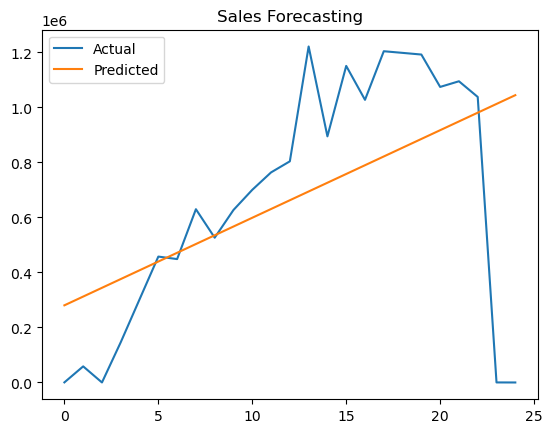

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly['time'], y, label='Actual')
plt.plot(monthly['time'], predictions, label='Predicted')
plt.legend()
plt.title("Sales Forecasting")
plt.show()

In [26]:
df.to_csv("final_dataset.csv", index=False)